In [1]:
# ============================================================
# FINAL PROJECT RESULTS SUMMARY
# ============================================================
# Informative MRI Slice Selection for Autism Spectrum
# Disorder Classification Using Deep Learning
#
# This notebook summarizes Experiments 01–09 and presents
# the final experimental configuration and results.
# ============================================================

print("=" * 70)
print("FINAL PROJECT RESULTS SUMMARY")
print("=" * 70)

print()
print("Project:")
print("Informative MRI Slice Selection for Autism Spectrum")
print("Disorder Classification Using Deep Learning")

print()
print("Purpose:")
print("To summarize all completed experiments, compare their")
print("subject-level classification performance, and document")
print("the final selected configuration.")

print()
print("Experiments completed: 01–09")
print("Final experiment: Experiment 09")
print()
print("No model training or XAI computation will be performed")
print("in this summary notebook.")

print()
print("✅ Summary notebook initialized.")

FINAL PROJECT RESULTS SUMMARY

Project:
Informative MRI Slice Selection for Autism Spectrum
Disorder Classification Using Deep Learning

Purpose:
To summarize all completed experiments, compare their
subject-level classification performance, and document
the final selected configuration.

Experiments completed: 01–09
Final experiment: Experiment 09

No model training or XAI computation will be performed
in this summary notebook.

✅ Summary notebook initialized.


In [2]:
# ============================================================
# CELL 2 — DATASET AND VALIDATION SETUP
# ============================================================

print("=" * 70)
print("DATASET AND VALIDATION SETUP")
print("=" * 70)

print()
print("Dataset:")
print("ABIDE structural MRI dataset")

print()
print("Task:")
print("Subject-level ASD vs Control classification")

print()
print("Validation split:")
print("Validation slices  : 1,054")
print("Validation subjects : 6")

print()
print("Validation subjects:")
validation_subjects = {
    51460: "ASD",
    51463: "ASD",
    51466: "ASD",
    51475: "Control",
    51476: "Control",
    51487: "Control"
}

for subject, label in validation_subjects.items():
    print(f"SUB_ID {subject}: {label}")

print()
print("Important limitation:")
print("The validation set contains only 6 subjects.")
print("Therefore, each correctly/incorrectly classified subject")
print("changes accuracy by approximately 16.67 percentage points.")

print()
print("Image preprocessing:")
print("• Resize to 224 × 224")
print("• 3 image channels")
print("• Convert to float32")
print("• No /255 normalization")

print()
print("Classification rule:")
print("Mean subject probability >= 0.5 → ASD")
print("Mean subject probability < 0.5  → Control")

print()
print("✅ Dataset and validation setup documented.")

DATASET AND VALIDATION SETUP

Dataset:
ABIDE structural MRI dataset

Task:
Subject-level ASD vs Control classification

Validation split:
Validation slices  : 1,054
Validation subjects : 6

Validation subjects:
SUB_ID 51460: ASD
SUB_ID 51463: ASD
SUB_ID 51466: ASD
SUB_ID 51475: Control
SUB_ID 51476: Control
SUB_ID 51487: Control

Important limitation:
The validation set contains only 6 subjects.
Therefore, each correctly/incorrectly classified subject
changes accuracy by approximately 16.67 percentage points.

Image preprocessing:
• Resize to 224 × 224
• 3 image channels
• Convert to float32
• No /255 normalization

Classification rule:
Mean subject probability >= 0.5 → ASD
Mean subject probability < 0.5  → Control

✅ Dataset and validation setup documented.


In [4]:
# ============================================================
# CELL 3 — MASTER EXPERIMENT COMPARISON
# ============================================================

import pandas as pd

master_results = pd.DataFrame([
    {
        "EXPERIMENT": "01",
        "MODEL": "EfficientNet",
        "METHOD": "All-slice baseline",
        "ACCURACY": 16.67,
        "CORRECT_SUBJECTS": "1/6"
    },
    {
        "EXPERIMENT": "02",
        "MODEL": "EfficientNet",
        "METHOD": "SHAP + Permutation Importance",
        "ACCURACY": 33.33,
        "CORRECT_SUBJECTS": "2/6"
    },
    {
        "EXPERIMENT": "03",
        "MODEL": "EfficientNet",
        "METHOD": "Weighted XAI (SHAP 0.8 + Permutation 0.2), Top-K=5",
        "ACCURACY": 50.00,
        "CORRECT_SUBJECTS": "3/6"
    },
    {
        "EXPERIMENT": "04",
        "MODEL": "ResNet50",
        "METHOD": "All-slice baseline",
        "ACCURACY": 50.00,
        "CORRECT_SUBJECTS": "3/6"
    },
    {
        "EXPERIMENT": "05",
        "MODEL": "ResNet50",
        "METHOD": "XAI-guided selection",
        "ACCURACY": 50.00,
        "CORRECT_SUBJECTS": "3/6"
    },
    {
        "EXPERIMENT": "06",
        "MODEL": "SqueezeNet",
        "METHOD": "All-slice baseline",
        "ACCURACY": 66.67,
        "CORRECT_SUBJECTS": "4/6"
    },
    {
        "EXPERIMENT": "07",
        "MODEL": "SqueezeNet",
        "METHOD": "IG-guided regional/diverse selection, 10 slices/subject",
        "ACCURACY": 66.67,
        "CORRECT_SUBJECTS": "4/6"
    },
    {
        "EXPERIMENT": "08",
        "MODEL": "SqueezeNet",
        "METHOD": "Aggregation comparison using selected slices",
        "ACCURACY": 66.67,
        "CORRECT_SUBJECTS": "4/6"
    },
    {
        "EXPERIMENT": "09",
        "MODEL": "SqueezeNet",
        "METHOD": "IG-ranked diverse selection, K=5/10/20",
        "ACCURACY": 83.33,
        "CORRECT_SUBJECTS": "5/6"
    }
])

print("=" * 70)
print("MASTER EXPERIMENT COMPARISON — EXPERIMENTS 01–09")
print("=" * 70)

print()
display(master_results)

print()
print("Best observed validation accuracy:",
      f"{master_results['ACCURACY'].max():.2f}%")

print("Best experiment:",
      master_results.loc[
          master_results["ACCURACY"].idxmax(),
          "EXPERIMENT"
      ])

print()
print("⚠️ Accuracy values are subject-level validation accuracy")
print("based on 6 validation subjects.")

print()
print("✅ Master comparison created.")

MASTER EXPERIMENT COMPARISON — EXPERIMENTS 01–09



,EXPERIMENT,MODEL,METHOD,ACCURACY,CORRECT_SUBJECTS
0,01,EfficientNet,All-slice baseline,16.67,1/6
1,02,EfficientNet,SHAP + Permutation Importance,33.33,2/6
2,03,EfficientNet,"Weighted XAI (SHAP 0.8 + Permutation 0.2), Top...",50.00,3/6
3,04,ResNet50,All-slice baseline,50.00,3/6
4,05,ResNet50,XAI-guided selection,50.00,3/6
5,06,SqueezeNet,All-slice baseline,66.67,4/6
6,07,SqueezeNet,"IG-guided regional/diverse selection, 10 slice...",66.67,4/6
7,08,SqueezeNet,Aggregation comparison using selected slices,66.67,4/6
8,09,SqueezeNet,"IG-ranked diverse selection, K=5/10/20",83.33,5/6



Best observed validation accuracy: 83.33%
Best experiment: 09

⚠️ Accuracy values are subject-level validation accuracy
based on 6 validation subjects.

✅ Master comparison created.


In [5]:
# ============================================================
# CELL 4 — EXPERIMENT 09: SLICE COUNT COMPARISON
# ============================================================

exp09_results = pd.DataFrame([
    {
        "K": 5,
        "SLICES_PER_SUBJECT": 5,
        "TOTAL_SLICES": 30,
        "CORRECT_SUBJECTS": "5/6",
        "ACCURACY": 83.33
    },
    {
        "K": 8,
        "SLICES_PER_SUBJECT": 8,
        "TOTAL_SLICES": 48,
        "CORRECT_SUBJECTS": "4/6",
        "ACCURACY": 66.67
    },
    {
        "K": 10,
        "SLICES_PER_SUBJECT": 10,
        "TOTAL_SLICES": 60,
        "CORRECT_SUBJECTS": "5/6",
        "ACCURACY": 83.33
    },
    {
        "K": 15,
        "SLICES_PER_SUBJECT": 15,
        "TOTAL_SLICES": 90,
        "CORRECT_SUBJECTS": "4/6",
        "ACCURACY": 66.67
    },
    {
        "K": 20,
        "SLICES_PER_SUBJECT": 20,
        "TOTAL_SLICES": 120,
        "CORRECT_SUBJECTS": "5/6",
        "ACCURACY": 83.33
    }
])

print("=" * 70)
print("EXPERIMENT 09 — SLICE COUNT COMPARISON")
print("=" * 70)

print()
display(exp09_results)

best_accuracy = exp09_results["ACCURACY"].max()
best_k = exp09_results.loc[
    exp09_results["ACCURACY"] == best_accuracy,
    "K"
].tolist()

print()
print(f"Best validation accuracy: {best_accuracy:.2f}%")
print(f"Best K values: {best_k}")
print("Best subject-level result: 5/6")

print()
print("Selection method:")
print("Integrated Gradients-guided ranking")
print("with diverse slice selection from the ranked slices.")

print()
print("Subject-level aggregation:")
print("Mean predicted ASD probability")

print()
print("Classification threshold:")
print("Mean probability >= 0.5 → ASD")
print("Mean probability < 0.5  → Control")

print()
print("✅ Experiment 09 results documented.")

EXPERIMENT 09 — SLICE COUNT COMPARISON



,K,SLICES_PER_SUBJECT,TOTAL_SLICES,CORRECT_SUBJECTS,ACCURACY
0,5,5,30,5/6,83.33
1,8,8,48,4/6,66.67
2,10,10,60,5/6,83.33
3,15,15,90,4/6,66.67
4,20,20,120,5/6,83.33



Best validation accuracy: 83.33%
Best K values: [5, 10, 20]
Best subject-level result: 5/6

Selection method:
Integrated Gradients-guided ranking
with diverse slice selection from the ranked slices.

Subject-level aggregation:
Mean predicted ASD probability

Classification threshold:
Mean probability >= 0.5 → ASD
Mean probability < 0.5  → Control

✅ Experiment 09 results documented.


In [6]:
# ============================================================
# CELL 5 — FINAL SELECTED CONFIGURATION
# ============================================================

final_configuration = {
    "MODEL": "SqueezeNet",
    "XAI_METHOD": "Integrated Gradients",
    "SLICE_SELECTION": "IG-ranked diverse slice selection",
    "SELECTED_K": 5,
    "SLICES_PER_SUBJECT": 5,
    "TOTAL_VALIDATION_SLICES_USED": 30,
    "SUBJECT_AGGREGATION": "Mean predicted ASD probability",
    "CLASSIFICATION_THRESHOLD": 0.5,
    "VALIDATION_ACCURACY": 83.33,
    "CORRECT_SUBJECTS": "5/6"
}

print("=" * 70)
print("FINAL SELECTED CONFIGURATION")
print("=" * 70)

print()

for key, value in final_configuration.items():
    print(f"{key:<32}: {value}")

print()
print("Why K=5 was selected:")
print("• It achieved the highest observed validation accuracy.")
print("• It uses the fewest slices among the configurations")
print("  achieving 83.33% accuracy.")
print("• It therefore provides the most compact representation")
print("  among the tied best-performing K values.")

print()
print("⚠️ K=10 and K=20 also achieved 83.33% accuracy.")
print("Therefore, K=5 is selected as the most compact tied-best configuration,")
print("not because it achieved higher accuracy than K=10 or K=20.")

print()
print("✅ Final configuration documented.")

FINAL SELECTED CONFIGURATION

MODEL                           : SqueezeNet
XAI_METHOD                      : Integrated Gradients
SLICE_SELECTION                 : IG-ranked diverse slice selection
SELECTED_K                      : 5
SLICES_PER_SUBJECT              : 5
TOTAL_VALIDATION_SLICES_USED    : 30
SUBJECT_AGGREGATION             : Mean predicted ASD probability
CLASSIFICATION_THRESHOLD        : 0.5
VALIDATION_ACCURACY             : 83.33
CORRECT_SUBJECTS                : 5/6

Why K=5 was selected:
• It achieved the highest observed validation accuracy.
• It uses the fewest slices among the configurations
  achieving 83.33% accuracy.
• It therefore provides the most compact representation
  among the tied best-performing K values.

⚠️ K=10 and K=20 also achieved 83.33% accuracy.
Therefore, K=5 is selected as the most compact tied-best configuration,
not because it achieved higher accuracy than K=10 or K=20.

✅ Final configuration documented.


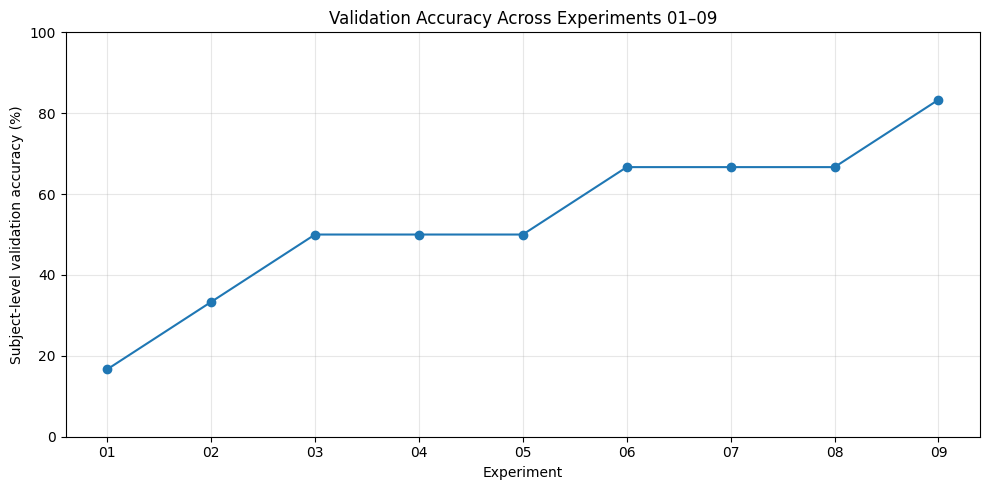


Accuracy progression:
Experiment 01 → 16.67%
Experiment 02 → 33.33%
Experiment 03 → 50.00%
Experiment 04 → 50.00%
Experiment 05 → 50.00%
Experiment 06 → 66.67%
Experiment 07 → 66.67%
Experiment 08 → 66.67%
Experiment 09 → 83.33%


In [7]:
# ============================================================
# CELL 6 — ACCURACY PROGRESSION ACROSS EXPERIMENTS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    master_results["EXPERIMENT"],
    master_results["ACCURACY"],
    marker="o"
)

plt.xlabel("Experiment")
plt.ylabel("Subject-level validation accuracy (%)")
plt.title("Validation Accuracy Across Experiments 01–09")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Accuracy progression:")
print("Experiment 01 → 16.67%")
print("Experiment 02 → 33.33%")
print("Experiment 03 → 50.00%")
print("Experiment 04 → 50.00%")
print("Experiment 05 → 50.00%")
print("Experiment 06 → 66.67%")
print("Experiment 07 → 66.67%")
print("Experiment 08 → 66.67%")
print("Experiment 09 → 83.33%")

In [8]:
# ============================================================
# CELL 7 — FINAL SUBJECT-LEVEL RESULTS (EXPERIMENT 09, K=5)
# ============================================================

final_subject_results = pd.DataFrame([
    {
        "SUB_ID": 51460,
        "TRUE_LABEL": "ASD",
        "PREDICTED_LABEL": "Control",
        "MEAN_PROBABILITY": 0.492323,
        "RESULT": "Incorrect"
    },
    {
        "SUB_ID": 51463,
        "TRUE_LABEL": "ASD",
        "PREDICTED_LABEL": "ASD",
        "MEAN_PROBABILITY": 0.506142,
        "RESULT": "Correct"
    },
    {
        "SUB_ID": 51466,
        "TRUE_LABEL": "ASD",
        "PREDICTED_LABEL": "ASD",
        "MEAN_PROBABILITY": 0.503523,
        "RESULT": "Correct"
    },
    {
        "SUB_ID": 51475,
        "TRUE_LABEL": "Control",
        "PREDICTED_LABEL": "Control",
        "MEAN_PROBABILITY": 0.487664,
        "RESULT": "Correct"
    },
    {
        "SUB_ID": 51476,
        "TRUE_LABEL": "Control",
        "PREDICTED_LABEL": "Control",
        "MEAN_PROBABILITY": 0.481771,
        "RESULT": "Correct"
    },
    {
        "SUB_ID": 51487,
        "TRUE_LABEL": "Control",
        "PREDICTED_LABEL": "Control",
        "MEAN_PROBABILITY": 0.497088,
        "RESULT": "Correct"
    }
])

print("=" * 70)
print("FINAL SUBJECT-LEVEL RESULTS — EXPERIMENT 09 (K=5)")
print("=" * 70)

print()
display(final_subject_results)

correct = (final_subject_results["RESULT"] == "Correct").sum()
total = len(final_subject_results)

print()
print(f"Correctly classified subjects : {correct}/{total}")
print(f"Validation accuracy            : {correct / total * 100:.2f}%")

print()
print("Classification threshold:")
print("Mean probability >= 0.5 → ASD")
print("Mean probability < 0.5  → Control")

print()
print("✅ Final subject-level results documented.")

FINAL SUBJECT-LEVEL RESULTS — EXPERIMENT 09 (K=5)



,SUB_ID,TRUE_LABEL,PREDICTED_LABEL,MEAN_PROBABILITY,RESULT
0,51460,ASD,Control,0.492323,Incorrect
1,51463,ASD,ASD,0.506142,Correct
2,51466,ASD,ASD,0.503523,Correct
3,51475,Control,Control,0.487664,Correct
4,51476,Control,Control,0.481771,Correct
5,51487,Control,Control,0.497088,Correct



Correctly classified subjects : 5/6
Validation accuracy            : 83.33%

Classification threshold:
Mean probability >= 0.5 → ASD
Mean probability < 0.5  → Control

✅ Final subject-level results documented.


In [9]:
# ============================================================
# CELL 8 — FINAL PERFORMANCE SUMMARY
# ============================================================

baseline_accuracy = master_results.loc[
    master_results["EXPERIMENT"] == "01",
    "ACCURACY"
].iloc[0]

final_accuracy = 83.33

baseline_slices = 1054
final_slices = 30

accuracy_improvement = final_accuracy - baseline_accuracy
slice_reduction_percent = (
    (baseline_slices - final_slices) / baseline_slices
) * 100

print("=" * 70)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 70)

print()
print(f"Initial baseline accuracy       : {baseline_accuracy:.2f}%")
print(f"Final validation accuracy       : {final_accuracy:.2f}%")
print(f"Absolute accuracy improvement   : +{accuracy_improvement:.2f} percentage points")

print()
print(f"Validation slices available     : {baseline_slices}")
print(f"Slices used in final method     : {final_slices}")
print(f"Slice reduction                 : {slice_reduction_percent:.2f}%")

print()
print("Final configuration:")
print("• Model: SqueezeNet")
print("• XAI: Integrated Gradients")
print("• Selection: IG-ranked diverse slice selection")
print("• K: 5 slices per subject")
print("• Aggregation: Mean predicted ASD probability")
print("• Threshold: 0.5")

print()
print("Final result:")
print("• 5 out of 6 validation subjects correctly classified")
print("• Subject-level validation accuracy: 83.33%")

print()
print("⚠️ The validation set contains only 6 subjects.")
print("Therefore, the observed accuracy should be interpreted as")
print("an experimental validation result rather than a definitive")
print("estimate of real-world generalization performance.")

print()
print("✅ Final performance summary documented.")

FINAL PERFORMANCE SUMMARY

Initial baseline accuracy       : 16.67%
Final validation accuracy       : 83.33%
Absolute accuracy improvement   : +66.66 percentage points

Validation slices available     : 1054
Slices used in final method     : 30
Slice reduction                 : 97.15%

Final configuration:
• Model: SqueezeNet
• XAI: Integrated Gradients
• Selection: IG-ranked diverse slice selection
• K: 5 slices per subject
• Aggregation: Mean predicted ASD probability
• Threshold: 0.5

Final result:
• 5 out of 6 validation subjects correctly classified
• Subject-level validation accuracy: 83.33%

⚠️ The validation set contains only 6 subjects.
Therefore, the observed accuracy should be interpreted as
an experimental validation result rather than a definitive
estimate of real-world generalization performance.

✅ Final performance summary documented.


In [10]:
# ============================================================
# CELL 9 — FINAL RESEARCH FINDINGS
# ============================================================

print("=" * 70)
print("FINAL RESEARCH FINDINGS")
print("=" * 70)

print()

print("1. MODEL PERFORMANCE")
print("-" * 70)
print("The initial EfficientNet all-slice baseline achieved 16.67%")
print("subject-level validation accuracy.")
print("The best observed result was achieved using SqueezeNet with")
print("Integrated Gradients-guided diverse slice selection.")
print("The final observed validation accuracy was 83.33% (5/6 subjects).")

print()

print("2. EFFECT OF XAI-GUIDED SLICE SELECTION")
print("-" * 70)
print("The experiments demonstrate that informative slice selection")
print("can substantially reduce the number of slices processed at")
print("the subject level while maintaining strong observed validation")
print("performance on the available validation subjects.")

print()

print("3. SLICE REDUCTION")
print("-" * 70)
print("The final K=5 configuration uses only 5 slices per subject.")
print("This corresponds to 30 slices across 6 validation subjects,")
print("compared with 1,054 available validation slices.")
print("This represents a 97.15% reduction in the number of slices used.")

print()

print("4. BEST SLICE COUNT")
print("-" * 70)
print("K=5, K=10, and K=20 all achieved 83.33% validation accuracy.")
print("K=5 was selected because it provides the most compact")
print("representation among the tied best-performing configurations.")

print()

print("5. SUBJECT-LEVEL CLASSIFICATION")
print("-" * 70)
print("Five of the six validation subjects were correctly classified.")
print("One ASD subject (SUB_ID 51460) was classified as Control.")
print("All three Control subjects in the final K=5 configuration")
print("were correctly classified.")

print()

print("6. INTERPRETATION")
print("-" * 70)
print("The results support the feasibility of using XAI-guided")
print("slice selection as a method for reducing the number of MRI")
print("slices required for subject-level classification.")

print()

print("7. IMPORTANT LIMITATION")
print("-" * 70)
print("Only six validation subjects were available.")
print("Therefore, the 83.33% result should be considered an")
print("experimental validation result and not a definitive measure")
print("of real-world model generalization.")

print()
print("✅ Final research findings documented.")

FINAL RESEARCH FINDINGS

1. MODEL PERFORMANCE
----------------------------------------------------------------------
The initial EfficientNet all-slice baseline achieved 16.67%
subject-level validation accuracy.
The best observed result was achieved using SqueezeNet with
Integrated Gradients-guided diverse slice selection.
The final observed validation accuracy was 83.33% (5/6 subjects).

2. EFFECT OF XAI-GUIDED SLICE SELECTION
----------------------------------------------------------------------
The experiments demonstrate that informative slice selection
can substantially reduce the number of slices processed at
the subject level while maintaining strong observed validation
performance on the available validation subjects.

3. SLICE REDUCTION
----------------------------------------------------------------------
The final K=5 configuration uses only 5 slices per subject.
This corresponds to 30 slices across 6 validation subjects,
compared with 1,054 available validation slices.
This

In [11]:
# ============================================================
# CELL 10 — FINAL PROJECT CONCLUSION
# ============================================================

print("=" * 70)
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print()

print("CONCLUSION")
print("-" * 70)

print(
    "This project investigated an explainable deep learning approach "
    "for subject-level ASD classification from structural MRI slices "
    "by identifying informative slices using XAI techniques."
)

print()

print(
    "Across nine completed experiments, the observed subject-level "
    "validation accuracy improved from 16.67% with the initial "
    "EfficientNet all-slice baseline to 83.33% with the final "
    "SqueezeNet and Integrated Gradients-guided slice selection approach."
)

print()

print(
    "The final selected configuration uses five IG-ranked diverse "
    "slices per subject and mean probability aggregation. It correctly "
    "classified 5 of the 6 validation subjects while using only 30 "
    "slices instead of the 1,054 available validation slices, "
    "representing a 97.15% reduction in the number of slices used."
)

print()

print(
    "K=5, K=10, and K=20 produced the same observed validation "
    "accuracy of 83.33%. K=5 was selected as the final configuration "
    "because it achieved the tied-best accuracy using the fewest slices."
)

print()

print(
    "Overall, the experiments provide preliminary evidence that "
    "XAI-guided MRI slice selection can reduce the number of slices "
    "required for subject-level classification while retaining the "
    "observed validation performance."
)

print()

print(
    "However, the validation set contained only six subjects. "
    "Therefore, the reported 83.33% accuracy represents an experimental "
    "validation result and should not be interpreted as a definitive "
    "measure of clinical or real-world generalization."
)

print()
print("STATUS")
print("-" * 70)
print("Experiments completed : 01–09")
print("Final experiment      : 09")
print("Final configuration   : SqueezeNet + Integrated Gradients + K=5")
print("Final accuracy        : 83.33% (5/6 subjects)")
print("Slice reduction       : 97.15%")
print()
print("✅ FINAL PROJECT RESULTS SUMMARY COMPLETE.")

FINAL PROJECT CONCLUSION

CONCLUSION
----------------------------------------------------------------------
This project investigated an explainable deep learning approach for subject-level ASD classification from structural MRI slices by identifying informative slices using XAI techniques.

Across nine completed experiments, the observed subject-level validation accuracy improved from 16.67% with the initial EfficientNet all-slice baseline to 83.33% with the final SqueezeNet and Integrated Gradients-guided slice selection approach.

The final selected configuration uses five IG-ranked diverse slices per subject and mean probability aggregation. It correctly classified 5 of the 6 validation subjects while using only 30 slices instead of the 1,054 available validation slices, representing a 97.15% reduction in the number of slices used.

K=5, K=10, and K=20 produced the same observed validation accuracy of 83.33%. K=5 was selected as the final configuration because it achieved the tied-

In [12]:
# ============================================================
# CELL 11 — SAVE FINAL SUMMARY FILES
# ============================================================

SUMMARY_DIR = "/content/drive/MyDrive/ASD_XAI_Project/experiment_10_final_project_results_summary"

import os
os.makedirs(SUMMARY_DIR, exist_ok=True)

# Save master experiment comparison
master_results.to_csv(
    os.path.join(SUMMARY_DIR, "master_experiment_comparison.csv"),
    index=False
)

# Save Experiment 09 K comparison
exp09_results.to_csv(
    os.path.join(SUMMARY_DIR, "experiment_09_k_comparison.csv"),
    index=False
)

# Save final subject-level results
final_subject_results.to_csv(
    os.path.join(SUMMARY_DIR, "final_subject_level_results.csv"),
    index=False
)

# Save final configuration
pd.DataFrame([final_configuration]).to_csv(
    os.path.join(SUMMARY_DIR, "final_configuration.csv"),
    index=False
)

# Save overall performance summary
performance_summary = pd.DataFrame([{
    "INITIAL_BASELINE_ACCURACY": baseline_accuracy,
    "FINAL_ACCURACY": final_accuracy,
    "ACCURACY_IMPROVEMENT_POINTS": accuracy_improvement,
    "VALIDATION_SLICES": baseline_slices,
    "FINAL_SLICES": final_slices,
    "SLICE_REDUCTION_PERCENT": slice_reduction_percent,
    "CORRECT_SUBJECTS": "5/6"
}])

performance_summary.to_csv(
    os.path.join(SUMMARY_DIR, "final_performance_summary.csv"),
    index=False
)

print("=" * 70)
print("FINAL SUMMARY FILES SAVED")
print("=" * 70)

print()
print("Location:")
print(SUMMARY_DIR)

print()
print("Files created:")
print("1. master_experiment_comparison.csv")
print("2. experiment_09_k_comparison.csv")
print("3. final_subject_level_results.csv")
print("4. final_configuration.csv")
print("5. final_performance_summary.csv")

print()
print("✅ All final summary results saved to Google Drive.")

FINAL SUMMARY FILES SAVED

Location:
/content/drive/MyDrive/ASD_XAI_Project/experiment_10_final_project_results_summary

Files created:
1. master_experiment_comparison.csv
2. experiment_09_k_comparison.csv
3. final_subject_level_results.csv
4. final_configuration.csv
5. final_performance_summary.csv

✅ All final summary results saved to Google Drive.


In [14]:
# ============================================================
# CELL 12 — FINAL FILE VERIFICATION
# ============================================================

import os

expected_files = [
    "master_experiment_comparison.csv",
    "experiment_09_k_comparison.csv",
    "final_subject_level_results.csv",
    "final_configuration.csv",
    "final_performance_summary.csv"
]

print("=" * 70)
print("FINAL FILE VERIFICATION")
print("=" * 70)

print()

all_found = True

for filename in expected_files:
    filepath = os.path.join(SUMMARY_DIR, filename)

    if os.path.exists(filepath):
        print(f"OK - {filename}")
    else:
        print(f"NOT FOUND - {filename}")
        all_found = False

print()

if all_found:
    print("ALL FINAL PROJECT RESULT FILES VERIFIED.")
    print()
    print("FINAL PROJECT STATUS: COMPLETE")
else:
    print("One or more files could not be found.")

FINAL FILE VERIFICATION

OK - master_experiment_comparison.csv
OK - experiment_09_k_comparison.csv
OK - final_subject_level_results.csv
OK - final_configuration.csv
OK - final_performance_summary.csv

ALL FINAL PROJECT RESULT FILES VERIFIED.

FINAL PROJECT STATUS: COMPLETE
